In [1]:
#!/bin/bash
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:05<00:00, 214MB/s]



In [2]:

!unzip /content/dogsvscats.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/dogs/dog.4419.jpg  
  inflating: train/dogs/dog.442.jpg  
  inflating: train/dogs/dog.4420.jpg  
  inflating: train/dogs/dog.4421.jpg  
  inflating: train/dogs/dog.4422.jpg  
  inflating: train/dogs/dog.4424.jpg  
  inflating: train/dogs/dog.4425.jpg  
  inflating: train/dogs/dog.4426.jpg  
  inflating: train/dogs/dog.4427.jpg  
  inflating: train/dogs/dog.4431.jpg  
  inflating: train/dogs/dog.4433.jpg  
  inflating: train/dogs/dog.4436.jpg  
  inflating: train/dogs/dog.4438.jpg  
  inflating: train/dogs/dog.4439.jpg  
  inflating: train/dogs/dog.444.jpg  
  inflating: train/dogs/dog.4440.jpg  
  inflating: train/dogs/dog.4441.jpg  
  inflating: train/dogs/dog.4442.jpg  
  inflating: train/dogs/dog.4443.jpg  
  inflating: train/dogs/dog.4444.jpg  
  inflating: train/dogs/dog.4445.jpg  
  inflating: train/dogs/dog.4446.jpg  
  inflating: train/dogs/dog.445.jpg  
  inflating: train/dogs/dog.4450.jpg  
  inflating: tra

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from keras import  Sequential
from keras.layers import Dense,Conv2D ,MaxPooling2D ,Flatten ,BatchNormalization,Dropout

## Understanding Generators

**Generators** are special functions in Python that allow you to declare a function that behaves like an iterator. They are particularly useful for working with large sequences of data, as they produce items one at a time, only when requested, rather than building the entire sequence in memory.

### How Generators Work

The key to generators is the `yield` keyword. When a generator function is called, it returns a generator object without executing any code. The code inside the function only runs when `next()` is called on the generator object, or when it's used in a `for` loop.

- **`yield` vs. `return`**:
  - `return` terminates a function and sends a single value back to the caller.
  - `yield` pauses the function's execution, sends a value back to the caller, and saves all its local state. When the function is resumed, it continues from where it left off.

### Why Use Generators?

1.  **Memory Efficiency**: Generators don't store the entire sequence in memory. They generate values on the fly, which is crucial for handling very large datasets that wouldn't fit into RAM (e.g., loading images for machine learning, processing large log files).

2.  **Performance**: For infinite sequences or very large finite sequences, generators can provide better performance because they avoid the overhead of creating and storing a complete data structure.

3.  **Readability and Simplicity**: They allow you to write elegant and concise code for data streaming.

4.  **Lazy Evaluation**: Values are computed only when they are needed. This is efficient when not all values in a sequence are required.

### Example

Consider a function to generate Fibonacci numbers:

```python
def fibonacci_generator():
    a, b = 0, 1
    while True:
        yield a
        a, b = b, a + b

# Using the generator
fib = fibonacci_generator()
for _ in range(5):
    print(next(fib))
# Output:
# 0
# 1
# 1
# 2
# 3
```

In the context of machine learning, especially with deep learning frameworks like TensorFlow/Keras, generators are extensively used (e.g., `ImageDataGenerator`) to feed training data to models in small batches without loading the entire dataset into memory at once. This significantly reduces RAM usage and prevents out-of-memory errors.

https://keras.io/api/data_loading/image/ link of it
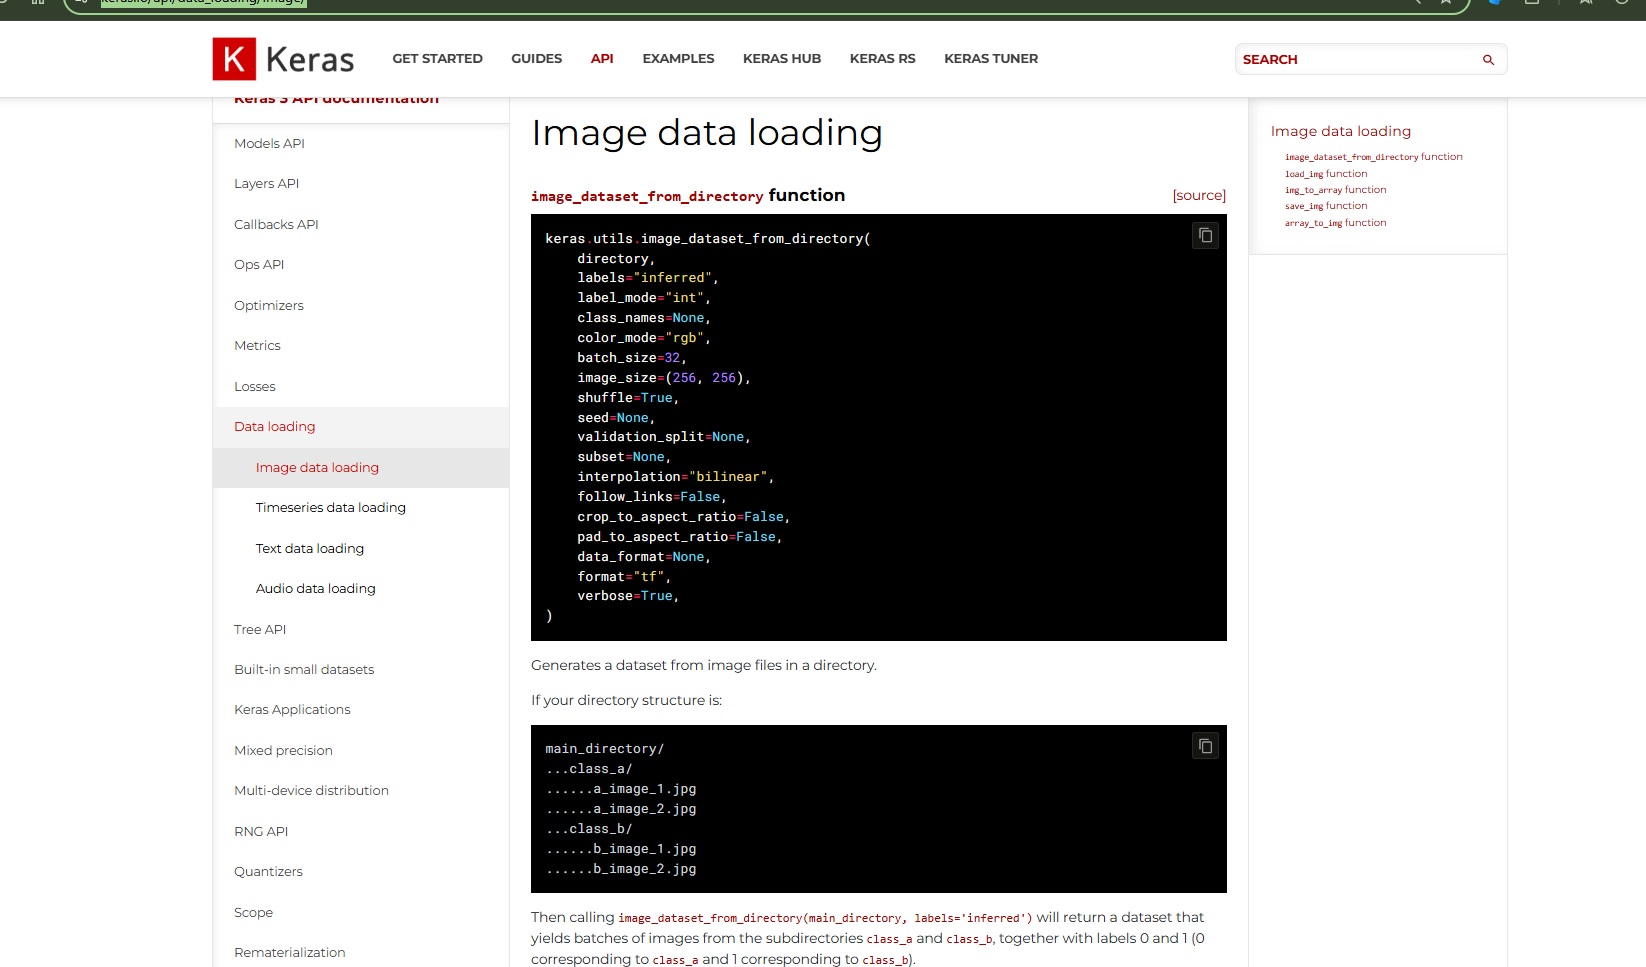

In [39]:
#  now  using it

# Appling it on the train images

train_ds=keras.utils.image_dataset_from_directory(
    directory ='/content/train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),

)

# Capture class_names immediately after creation, before mapping
class_names = train_ds.class_names


test_ds=keras.utils.image_dataset_from_directory(
    directory ='/content/test',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),

)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


*This code snippet defines a function called process which takes an image and its label as input. Inside this function, tf.cast(image/255. ,tf.float32)   `normalizes the image pixel values. Image pixel values typically range from 0 to 255.*`

```By dividing them by 255 and casting them to a tf.float32 data type, the pixel values are scaled to a range between 0 and 1. ```

This normalization is a common preprocessing step for neural networks. Finally, train_ds.map(process) and test_ds.map(process) apply this process function to every image in both the train_ds and test_ds datasets, ensuring all images are normalized before being used for training or evaluation.

In [5]:
#  here the images in the  form of  numpy array and  also  the numpy  each   vale is the  range  from 0 to 256
# We Need  to  normalized it  to place them in the  range  of  0 to 1

def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
test_ds=test_ds.map(process)


# Create CNN  Model


In [6]:


model = Sequential()

model.add(Conv2D(32 ,kernel_size=(3,3 ) ,padding='valid' ,activation='relu' ,input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2) ,strides=2 ,padding='valid'))

model.add(Conv2D(64 ,kernel_size=(3,3 ) ,padding='valid' ,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2) ,strides=2 ,padding='valid'))

model.add(Conv2D(128 ,kernel_size=(3,3 ) ,padding='valid' ,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2) ,strides=2 ,padding='valid'))


model.add(Flatten())

model.add(Dense(128 ,activation='relu'))
model.add(Dense(64 ,activation='relu'))
model.add(Dense(1 ,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
model.compile(optimizer='adam' ,loss ='binary_crossentropy' ,metrics = ['accuracy'])

In [9]:
history = model.fit(train_ds ,  epochs = 10   , validation_data=test_ds)

#  32*625 =20000

#   the  runtime  well slow so use the tpu are  gpu

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 92ms/step - accuracy: 0.6271 - loss: 1.2588 - val_accuracy: 0.6444 - val_loss: 0.8493
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7428 - loss: 0.5385 - val_accuracy: 0.7478 - val_loss: 0.5175
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.8020 - loss: 0.4247 - val_accuracy: 0.7934 - val_loss: 0.4577
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.8443 - loss: 0.3536 - val_accuracy: 0.7788 - val_loss: 0.5353
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8884 - loss: 0.2660 - val_accuracy: 0.7904 - val_loss: 0.5506
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9279 - loss: 0.1753 - val_accuracy: 0.7918 - val_loss: 0.7223
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 90ms/step - accuracy: 0.9549 - loss: 0.1155 - val_accuracy: 0.7890 - val_loss: 0.8072
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 95ms/step - accuracy: 0.9699 - loss: 0.0828 - 

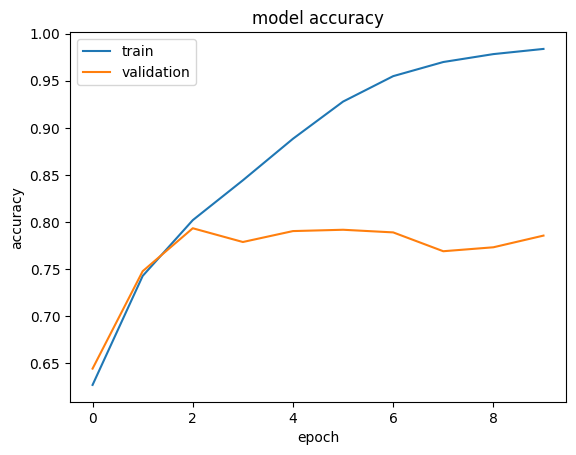

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


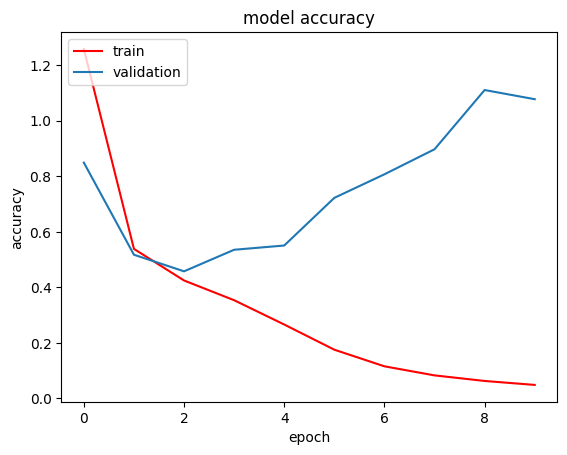

In [11]:
plt.plot(history.history['loss'] ,  color= 'red')
plt.plot(history.history['val_loss']  ,label ='validation')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


In [101]:
#  here is  occure the overfiting  showing on the Validation data  So we appling some  regularization  Techniques   for  over come  This overFiting

# Data Argumentation
#  L1 and  L2 Regularization
#  Droup Out
#  Batch  normalization
#  Reduce  complexity
#  add  more  data


In [108]:
model = Sequential()

model.add(Conv2D(32 ,kernel_size=(3,3 ) ,padding='valid' ,activation='relu' ,input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2) ,strides=2 ,padding='valid'))
model.add(Dropout(0.25))

model.add(Conv2D(64 ,kernel_size=(3,3 ) ,padding='valid' ,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2) ,strides=2 ,padding='valid'))
model.add(Dropout(0.30))

model.add(Conv2D(128 ,kernel_size=(3,3 ) ,padding='valid' ,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2) ,strides=2 ,padding='valid'))
model.add(Dropout(0.35))

model.add(Flatten())

model.add(Dense(128 ,activation='relu'  ,     kernel_regularizer=tf.keras.regularizers.l2(0.001))  )
model.add(Dropout(0.5))

model.add(Dense(64 ,activation='relu'  ,    kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(Dropout(0.3))

model.add(Dense(1 ,activation='sigmoid'))


In [109]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [110]:
model.compile(optimizer='adam' ,loss ='binary_crossentropy' ,metrics = ['accuracy'])


In [111]:
history = model.fit(train_ds ,  epochs = 10   , validation_data=test_ds)

#  32*625 =20000

#   the  runtime  well slow so use the tpu are  gpu

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 91ms/step - accuracy: 0.5021 - loss: 2.5014 - val_accuracy: 0.5382 - val_loss: 1.4819
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 88ms/step - accuracy: 0.4940 - loss: 1.2321 - val_accuracy: 0.5146 - val_loss: 1.0915
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.4990 - loss: 1.0693 - val_accuracy: 0.5128 - val_loss: 1.2636
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.4965 - loss: 1.2420 - val_accuracy: 0.4994 - val_loss: 2.2002
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - accuracy: 0.4972 - loss: 1.2724 - val_accuracy: 0.5050 - val_loss: 1.2863
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.4986 - loss: 0.9813 - val_accuracy: 0.5186 - val_loss: 0.9331
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.4960 - loss: 0.8289 - val_accuracy: 0.5044 - val_loss: 0.7634
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.4961 - loss: 0.8101 - 

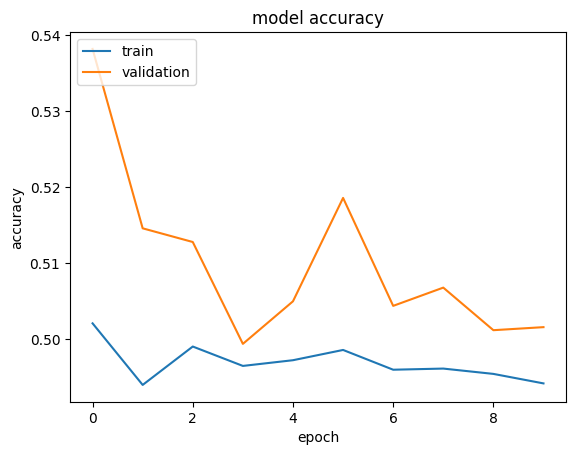

In [112]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


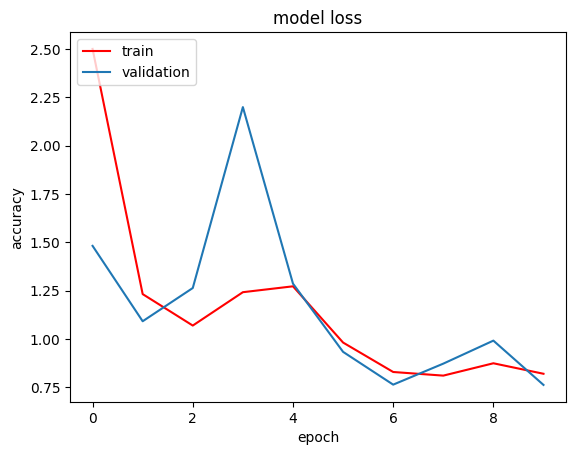

In [113]:
plt.plot(history.history['loss'] ,  color= 'red')
plt.plot(history.history['val_loss']  ,label ='validation')
plt.title('model loss')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


In [114]:

import cv2
test_image=cv2.imread('/content/cat.jpg')

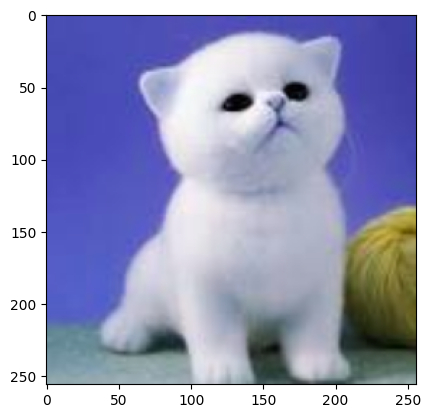

In [141]:
plt.imshow(test_image)



In [142]:
test_image.shape

(256, 256, 3)

In [143]:
test_image=cv2.resize(test_image,(256,256))

In [144]:
test_input= test_image.reshape((1,256,256,3))

In [145]:
prediction = model.predict(test_input)
print(f"Raw prediction output: {prediction}")

# class_names is now retrieved earlier from the original dataset creation
print(f"Class names from dataset: {class_names}")

# The model outputs a single probability, which is typically for the 'positive' class (class 1).
# So, prediction[0][0] is the probability of being a 'dog' (assuming class_names = ['cat', 'dog'])
prob_dog = prediction[0][0]
prob_cat = 1 - prob_dog

print(f"Probability of Cat: {prob_cat:.4f}")
print(f"Probability of Dog: {prob_dog:.4f}")

if prob_dog < 0.5:
    print(f"Predicted class: {class_names[0]} (Cat)")
else:
    print(f"Predicted class: {class_names[1]} (Dog)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Raw prediction output: [[0.49588743]]
Class names from dataset: ['cats', 'dogs']
Probability of Cat: 0.5041
Probability of Dog: 0.4959
Predicted class: cats (Cat)


# Prediction for the Dog   what should Answer    for the  unseen Dog image

In [146]:

import cv2
test_image1=cv2.imread('/content/dog1.webp')

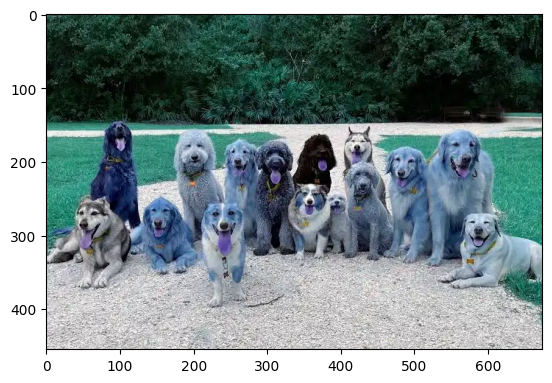

In [122]:
plt.imshow(test_image1)



In [147]:
test_image1.shape

(455, 674, 3)

In [148]:
test_image1=cv2.resize(test_image1,(256,256))

In [149]:
test_input1= test_image1.reshape((1,256,256,3))

In [150]:
prediction = model.predict(test_input1)
print(f"Raw prediction output: {prediction}")

# class_names is now retrieved earlier from the original dataset creation
print(f"Class names from dataset: {class_names}")

# The model outputs a single probability, which is typically for the 'positive' class (class 1).
# So, prediction[0][0] is the probability of being a 'dog' (assuming class_names = ['cat', 'dog'])
prob_dog = prediction[0][0]
prob_cat = 1 - prob_dog

print(f"Probability of Cat: {prob_cat:.4f}")
print(f"Probability of Dog: {prob_dog:.4f}")

if prob_dog < 0.5:
    print(f"Predicted class: {class_names[0]} (Cat)")
else:
    print(f"Predicted class: {class_names[1]} (Dog)")

# Note: The model is consistently predicting 'Cat' with low confidence because its overall accuracy
# is very low (around 50%), meaning it has not learned to distinguish between classes effectively,
# as shown by the confusion matrix. To improve predictions, the model itself needs to be re-trained
# or a different approach (e.g., transfer learning) should be considered.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw prediction output: [[0.50322795]]
Class names from dataset: ['cats', 'dogs']
Probability of Cat: 0.4968
Probability of Dog: 0.5032
Predicted class: dogs (Dog)


In [151]:
test_input1= test_image1.reshape((1,256,256,3))


In [152]:
prediction = model.predict(test_input1)
print(f"Raw prediction output: {prediction}")

# class_names is now retrieved earlier from the original dataset creation
print(f"Class names from dataset: {class_names}")

# The model outputs a single probability, which is typically for the 'positive' class (class 1).
# So, prediction[0][0] is the probability of being a 'dog' (assuming class_names = ['cat', 'dog'])
prob_dog = prediction[0][0]
prob_cat = 1 - prob_dog

print(f"Probability of Cat: {prob_cat:.4f}")
print(f"Probability of Dog: {prob_dog:.4f}")

if prob_dog < 0.5:
    print(f"Predicted class: {class_names[0]} (Cat)")
else:
    print(f"Predicted class: {class_names[1]} (Dog)")

# Note: The model is consistently predicting 'Cat' with low confidence because its overall accuracy
# is very low (around 50%), meaning it has not learned to distinguish between classes effectively,
# as shown by the confusion matrix. To improve predictions, the model itself needs to be re-trained
# or a different approach (e.g., transfer learning) should be considered.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Raw prediction output: [[0.50322795]]
Class names from dataset: ['cats', 'dogs']
Probability of Cat: 0.4968
Probability of Dog: 0.5032
Predicted class: dogs (Dog)


### Confusion Matrix

To get a better understanding of how the model is performing on the test set, especially with its low accuracy, let's compute and visualize a confusion matrix. This will show the counts of true positive, true negative, false positive, and false negative predictions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━

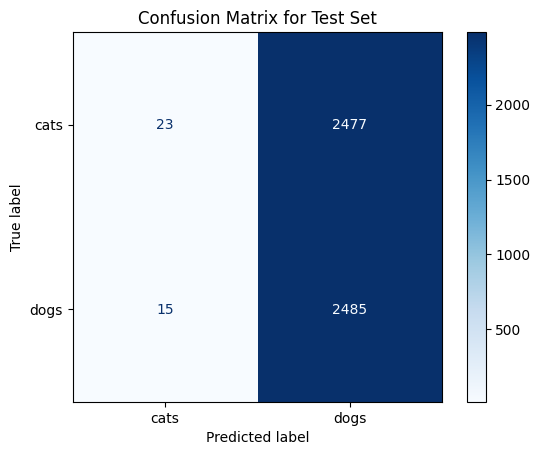

In [153]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions from the test dataset

all_labels = []
all_predictions = []

for images, labels in test_ds:
    preds = model.predict(images)
    # Assuming binary classification with sigmoid output, threshold at 0.5
    predicted_classes = (preds > 0.5).astype(int)
    all_predictions.extend(predicted_classes.flatten())
    all_labels.extend(labels.numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Test Set')
plt.show()

In [61]:
model.predict(test_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step


array([[0.49908164],
       [0.49908164],
       [0.49908164],
       ...,
       [0.49908164],
       [0.49908164],
       [0.49908164]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71m

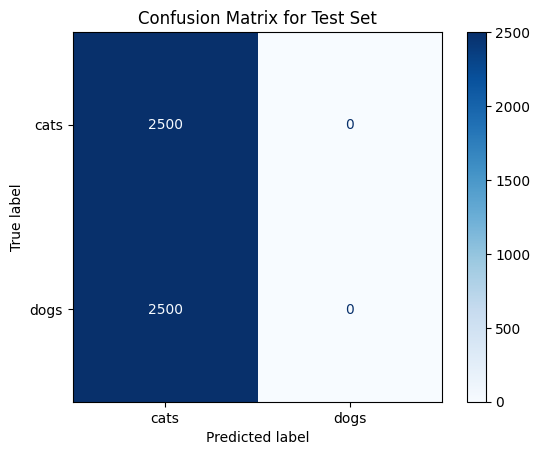

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions from the test dataset

all_labels = []
all_predictions = []

for images, labels in test_ds:
    preds = model.predict(images)
    # Assuming binary classification with sigmoid output, threshold at 0.5
    predicted_classes = (preds > 0.5).astype(int)
    all_predictions.extend(predicted_classes.flatten())
    all_labels.extend(labels.numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Test Set')
plt.show()